# Exoplanetary System Habitability Analysis using GNNs

## Context

**1. Introduction**

The goal of this project is to **predict the habitability of planetary systems by representing them as graphs**. In astronomy, a planet’s environment is not isolated. It depends on its host star and its position within the system. For example, Earth would not be habitable if it were orbiting a much hotter star at the same distance, or if its orbit were highly eccentric (non-circular) due to gravitational interference from other planets. We will use Graph Neural Networks (GNNs) to process these complex spatial relationships.

**2. Dataset**

We are using the NASA Exoplanet Archive (Composite Data). This dataset includes physical parameters of thousands of exoplanets and their host stars.
- **Nodes**: Each planet and the host star will be a node.
- **Edges**: Connections between the star and its planets (representing gravitational and energetic influence).
- **Key Features**: Although the dataset contains nearly 100 different parameters, we will focus on a specific set of Key Features. These variables provide the essential physical information needed to detect our target: habitability.
    - **System Structure**
        - **`hostname` (Star Name)**: This is the ID of the star. It helps us group all planets that orbit the same star. Without this, we cannot build the network (the graph).
        - **`sy_pnum` (Number of Planets)**: It tells us how many planets are in the system. We use this to filter out systems with only one planet, as we need multiple nodes to see relationships.
    - **Planet Data**
        - **`pl_orbsmax` (Distance to Star)**: The most important factor. If a planet is too close, it burns; if it is too far, it freezes.
        - **`pl_rade` (Radius)**: Tells us the size. Is it a small rocky world like Earth or a giant gas ball like Jupiter? Life needs solid ground.
        - **`pl_bmasse` (Mass)**: The "weight" of the planet. High mass means crushing gravity; low mass means the planet cannot hold an atmosphere to breathe.
        - **`pl_insol` (Energy Received)**: The actual heat the planet gets from its star. This is the key to knowing if it is "habitable".
        - **`pl_orbeccen` (Orbit Shape)**: Tells us if the orbit is a perfect circle or a stretched oval. A stretched oval causes violent weather changes.
    - **Star Data**
        - **`st_teff` (Star Temperature)**: Tells us the color of the sun. Blue stars are super hot; red stars are cooler and smaller.
        - **`st_mass` (Star Mass)**: Bigger stars have stronger gravity but live very short lives. Small stars live longer, giving life more time to evolve.
        - **`st_met` (Star Metallurgy)**: This tells us if the star has "heavy materials" (like iron or rock). Stars with high metallurgy are more likely to have rocky planets like Earth.

**Note:** All information and column descriptions were taken from the official [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html).

**3. Objectives**

- **Data Engineering**: Clean and filter the NASA dataset, focusing on multi-planetary systems.

- **Graph Construction**: Transform the tabular data into graph structures using PyTorch Geometric.

- **Labeling**: Define a "Habitability Label" based on the Earth Similarity Index (ESI) logic (combining planet size and energy received).

- **Model Implementation**: Build a Graph Convolutional Network (GCN) with a Global Pooling layer to classify entire systems.

- **Handling Imbalance**: Use advanced ML techniques (like weighted loss functions) to handle the scarcity of habitable planets compared to gas giants.

## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data

/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Machine-Learning-Avanzado/.venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()
/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Machine-Learning-Avanzado/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Analysis

The first step in our pipeline is to load the raw data from the NASA Exoplanet Archive. 

The dataset is provided in a .csv format that includes several lines of metadata (comments starting with #). We use the comment parameter to skip these lines and load only the structured table.

In [2]:
file_path = 'data/astroData.csv'
df_raw = pd.read_csv(file_path, comment='#', low_memory=False)

print(f"Dataset loaded with {df_raw.shape[0]} planets and {df_raw.shape[1]} columns.")
df_raw.head()

Dataset loaded with 6286 planets and 84 columns.


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


Before selecting our final features, we need to understand the **quality of the data**. In exoplanet science, not all parameters are known for every planet. Some might have a measured radius but missing mass, or vice versa.

Missing data can be a problem for our GNN because each node in the graph needs complete information to perform calculations. Our **goals** in this section are:
- Identify which key columns have the most missing values.
- Decide if we should drop the rows with missing data or impute (estimate) them.

/tmp/ipykernel_35868/3416185707.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')


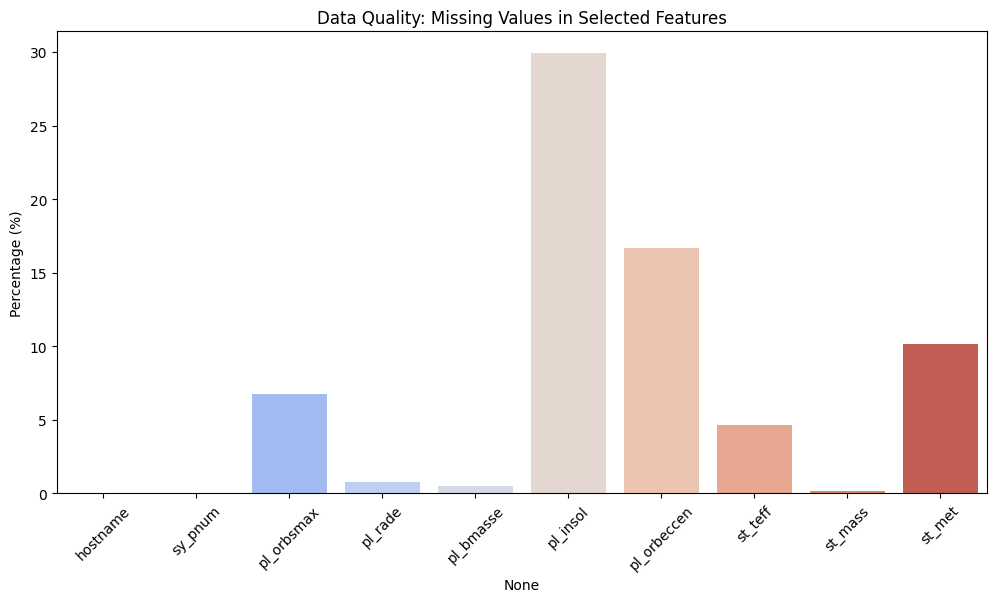

             Null Values  Percentage (%)
pl_insol            1880       29.907731
pl_orbeccen         1049       16.687878
st_met               640       10.181355
pl_orbsmax           426        6.776965
st_teff              294        4.677060
pl_rade               50        0.795418
pl_bmasse             31        0.493159
st_mass                9        0.143175
sy_pnum                0        0.000000
hostname               0        0.000000


In [3]:
# We only want to see the columns we are interested in for our project (explained which ones were selected above)
key_columns = [
    'hostname', 'sy_pnum',          
    'pl_orbsmax', 'pl_rade', 
    'pl_bmasse', 'pl_insol', 
    'pl_orbeccen',                  
    'st_teff', 'st_mass', 'st_met'
]

# Calculate null values and their percentage for the key columns
null_summary = pd.DataFrame({
    'Null Values': df_raw[key_columns].isnull().sum(),
    'Percentage (%)': (df_raw[key_columns].isnull().sum() / len(df_raw)) * 100
})

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')
plt.title('Data Quality: Missing Values in Selected Features')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.show()

print(null_summary.sort_values(by='Percentage (%)', ascending=False))

As we discovered, the **Insolation Flux (`pl_insol`) is our most problematic column because it has the highest amount of missing values (nearly 30%)**. Deleting 30% of our planets would be a massive loss of information for our Graph Neural Network.

**The Solution: Physical Imputation**
Instead of discarding this data, we can use a physical model to calculate the missing values. To do this, we need three specific data from our dataset:
1. **Stellar Radius (`st_rad`)**: To know the size of the light source
2. **Stellar Temperature (`st_teff`)**: To know the intensity of the heat.
3. **Distance (`pl_orbsmax`)**: To know how much the energy fades before reaching the planet.

**The Math Behind it**
We use the Stefan-Boltzmann Law and the Inverse Square Law. By comparing the exoplanet's host star to our Sun (which has a reference temperature of 5778K), we can estimate the energy flux using this formula:$$pl\_insol \approx \left( \frac{st\_rad}{pl\_orbsmax} \right)^2 \times \left( \frac{st\_teff}{5778} \right)^4$$

**Execution Strategy**
1. Identify planets where pl_insol is missing but the necessary data (st_rad, st_teff, pl_orbsmax) is present.
2. Apply the formula to "rescue" those planets.
3. We check how many data points were successfully recovered.
4. After this "rescue" operation, we will evaluate the status of other columns (like Eccentricity or Metallurgy) to decide the final cleaning strategy.

In [4]:
# 1. Count how many planets are missing 'pl_insol'
initial_nulls = df_raw['pl_insol'].isnull().sum()

# 2. Check if the data is available for those missing rows
# We need st_rad, st_teff, and pl_orbsmax
recoverable = (
    df_raw['pl_insol'].isnull() & 
    df_raw['st_rad'].notnull() & 
    df_raw['st_teff'].notnull() & 
    df_raw['pl_orbsmax'].notnull()
)

print(f"Total missing pl_insol: {initial_nulls}")
print(f"Planets that can be saved: {recoverable.sum()}")

Total missing pl_insol: 1880
Planets that can be saved: 1296


As the output shows, we were **unable to recover any missing values for `pl_insol`**.

Even though we have the physical formula, the analysis confirms that for every planet missing the Insolation Flux, at least one of the essential data (st_rad, st_teff, or pl_orbsmax) is also missing from the NASA database. Since we cannot "rescue" these 584 planets, we will proceed to remove them. This ensures our Graph Neural Network is trained only on confirmed, high-quality observational data.

/tmp/ipykernel_35868/1966132634.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')


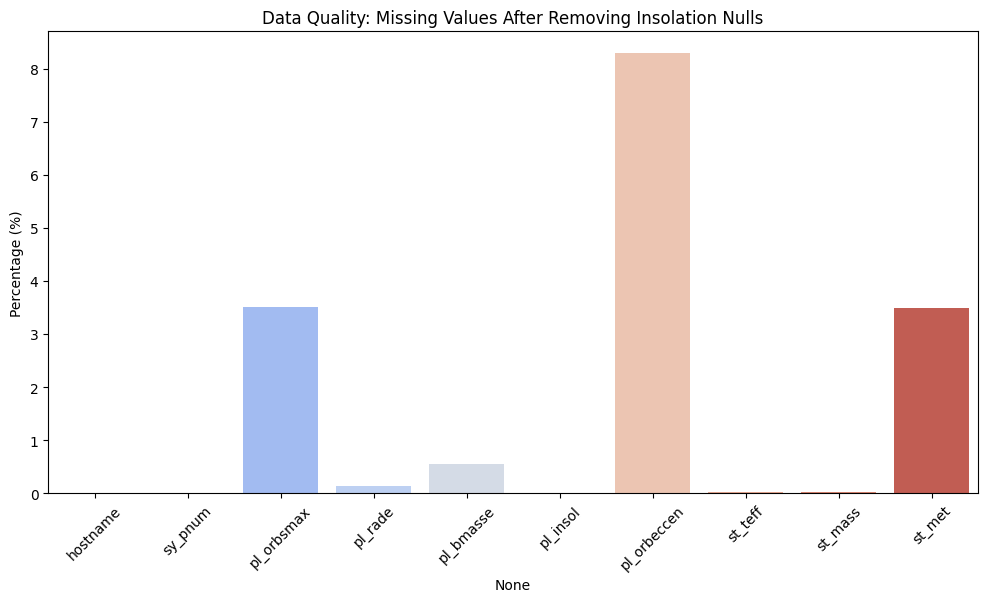

Total planets remaining: 4406
             Null Values  Percentage (%)
pl_orbeccen          365        8.284158
pl_orbsmax           155        3.517930
st_met               154        3.495234
pl_bmasse             24        0.544712
pl_rade                6        0.136178
st_teff                1        0.022696
st_mass                1        0.022696
hostname               0        0.000000
sy_pnum                0        0.000000
pl_insol               0        0.000000


In [5]:
# 1. Drop rows where 'pl_insol' is null
df_raw = df_raw.dropna(subset=['pl_insol']).copy()

# 2. Define our key features for the project
key_columns = [
    'hostname', 'sy_pnum',          
    'pl_orbsmax', 'pl_rade', 
    'pl_bmasse', 'pl_insol', 
    'pl_orbeccen',                  
    'st_teff', 'st_mass', 'st_met'
]

# 3. Calculate null values and their percentage for the key columns
null_summary = pd.DataFrame({
    'Null Values': df_raw[key_columns].isnull().sum(),
    'Percentage (%)': (df_raw[key_columns].isnull().sum() / len(df_raw)) * 100
})

# 4. Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=null_summary.index, y=null_summary['Percentage (%)'], palette='coolwarm')
plt.title('Data Quality: Missing Values After Removing Insolation Nulls')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.show()

print(f"Total planets remaining: {len(df_raw)}")
print(null_summary.sort_values(by='Percentage (%)', ascending=False))

After droping those planets with `pl_insol` null we identified that 9.3% (531 planets) are still missing the Eccentricity (pl_orbeccen) data. Before deciding to delete these rows or fill them with a random value, we must perform a "Sanity Check" on the distribution of the data. Now we hace the dilemma:
- **Option A (Drop)**: Lose 531 planets, which might weaken our Graph Neural Network.
- **Option B (Impute)**: Fill the gaps with the Median to keep the data volume high.

First, we will check the Median. In astronomy, missing eccentricity often implies that the orbit is near-circular. To verify this, we calculated the median of the existing data:

In [6]:
# Checking the median before deciding
print(f"The median for eccentricity is: {df_raw['pl_orbeccen'].median()}")

The median for eccentricity is: 0.0


Since the median is 0.0, imputing this value is scientifically sound. It aligns with the Circular Orbit Assumption used in astrophysics: unless proven otherwise, many orbits are treated as circular to simplify models.

Now, we apply the median imputation for Eccentricity and Metallicity, and then perform a final drop for the remaining columns that have less than 3% missing values.

In [7]:
# Impute the median for pl_orbeccen and st_met since they have a significant number of nulls but are still important features
df_raw['pl_orbeccen'] = df_raw['pl_orbeccen'].fillna(df_raw['pl_orbeccen'].median())
df_raw['st_met'] = df_raw['st_met'].fillna(df_raw['st_met'].median())

# Remove the remaining nulls in the critical columns for our analysis
final_critical_columns = ['pl_orbsmax', 'pl_rade', 'pl_bmasse', 'st_mass', 'st_teff']
df_final = df_raw.dropna(subset=final_critical_columns).copy()

# Check the final results
print(f"Total planets remaining after cleaning: {len(df_final)}")
print("\nFinal null check:")
print(df_final[key_columns].isnull().sum())

Total planets remaining after cleaning: 4221

Final null check:
hostname       0
sy_pnum        0
pl_orbsmax     0
pl_rade        0
pl_bmasse      0
pl_insol       0
pl_orbeccen    0
st_teff        0
st_mass        0
st_met         0
dtype: int64


## Exploratory Data Analysis (EDA)

Now that we have a clean dataset with 4.221 exoplanets and zero missing values, it is time to perform an Exploratory Data Analysis (EDA).

In this project, the EDA serves three main purposes:
1. **Understanding Distributions**: Are most planets Earth-sized or Jupiter-sized? Do they usually orbit close to their stars? This helps us understand the "nodes" of our future graph.
2. **Correlation Analysis**: How does the star's temperature (st_teff) affect the insolation (pl_insol)? Identifying these links helps us justify the "edges" in our GNN.
3. **Habitability Patterns**: We will look for the "Sweet Spot" (The Habitable Zone). By plotting features like distance vs. temperature, we can visually see where the most "Earth-like" candidates are located.
4. **Graph Topology**: We investigate how many planets belong to each stellar system. This determines the connectivity and complexity of the graphs that the model will process.

### Understanding Distributions

First, we are going to examine the **distribution of the physical sizes of the planets in our dataset**. By plotting a histogram of the Planetary Radius (`pl_rade`), we can identify which types of worlds are most common in our cleaned data. We will use a red dashed line to mark 1.0 Earth Radius as a reference point to see how many "Earth-like" candidates we have compared to larger "Gas Giants."

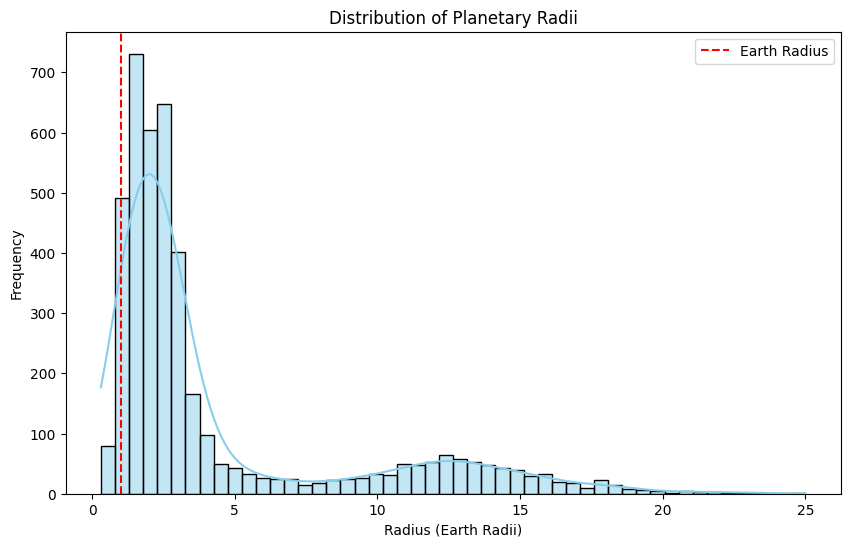

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final['pl_rade'], bins=50, kde=True, color='skyblue')
plt.axvline(1.0, color='red', linestyle='--', label='Earth Radius')
plt.title('Distribution of Planetary Radii')
plt.xlabel('Radius (Earth Radii)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

- **Prevalence of Super-Earths**: The largest peak in our data occurs between 1 and 4 Earth radii. These are known as Super-Earths and Mini-Neptunes. This is the most abundant type of planet in the galaxy, and our dataset reflects this reality perfectly.

- **The Gas Giant Population**: We see a second, smaller "mountain" around 10 to 15 Earth radii. These are the Gas Giants, similar in size to Jupiter. This confirms our dataset contains a diverse mix of planetary architectures.

- **Ideal for Habitability Research**: As the distribution is heavily concentrated near the Earth-size reference line, our Graph Neural Network will have a rich amount of data to learn the specific conditions of rocky, potentially habitable worlds rather than being overwhelmed by massive gas planets.

**Important Distinction: Size vs. Habitability**
It is important to note that being near the red line (1.0 Earth Radius) is a significant indicator, but it is not a 100% guarantee of habitability. To understand if a planet is truly "Earth-like," we must consider the "Habitability Triad":
1. **The Size (Radius)**: Tells us if the planet is likely rocky (like Earth) or a gas giant (like Jupiter). A radius near 1.0 is a great start.
2. **The Energy (Insolation)**: Even if a planet is the same size as Earth, if it is too close to its star, it will be a "Lava World." If it is too far, it will be an "Ice World."
3. **The Composition**: The density and atmosphere (which we can infer from mass and radius) also play a role.

**In conclusion for this EDA step**: The histogram confirms that we have many "nodes" (planets) with the correct size to be habitable. However, our Graph Neural Network will need to combine this size with the Insolation (`pl_insol`) and Stellar Temperature (`st_teff`) to decide if the planet actually sits in the "Goldilocks Zone."

### Correlation Analysis (Heatmap)

First, we are going to analyze **how our different features relate to each other** using a Correlation Matrix. This heatmap helps us understand the strength of the relationship between variables (from -1 to 1). For a Graph Neural Network, these correlations justify **why certain features** (like stellar mass and planetary distance) **are processed together**.

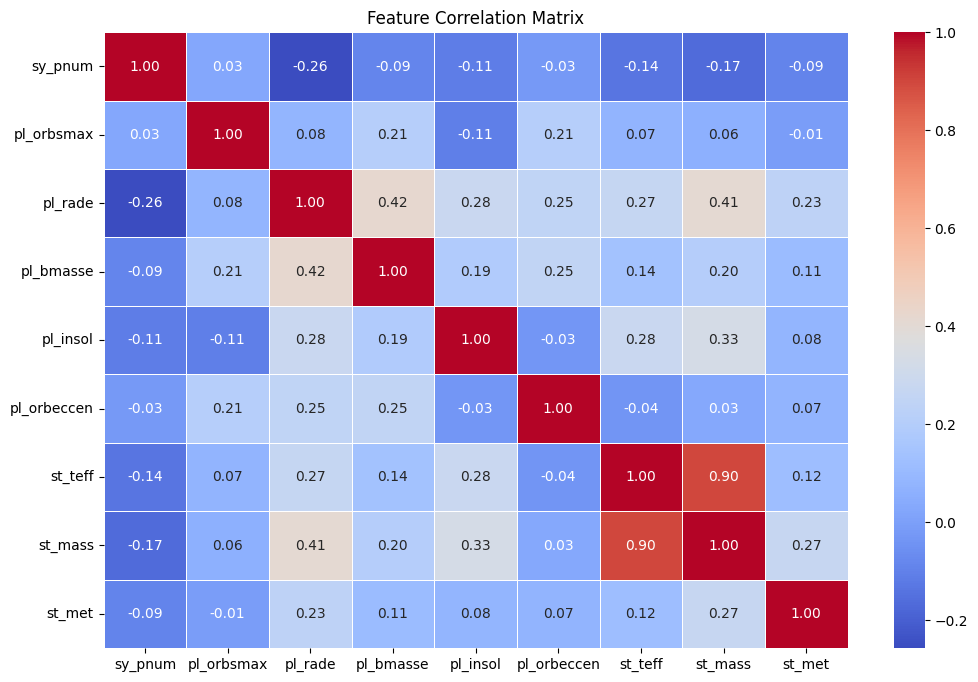

In [9]:
plt.figure(figsize=(12, 8))
# Just calculate the correlation for the numeric columns
corr_matrix = df_final[key_columns].select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

**Key Insights from the Heatmap**
- **The Stellar Connection (0.90)**: Look at the intersection of `st_teff` (temperature) and `st_mass` (mass). There is a 0.90 correlation. This makes perfect sense: in the main sequence, bigger stars are almost always hotter. This tells the GNN that the "host node" (the star) has very consistent properties.
- **Mass vs. Radius (0.42)**: There is a moderate positive correlation between `pl_bmasse` and `pl_rade`. This is expected: usually, the more massive a planet is, the larger its radius. However, it's not a 1.0 because a gas giant (like Jupiter) is much less dense than a rocky planet (like Earth).
- **The "Insolation" Drivers (0.28 & 0.33)**: Notice that `pl_insol` correlates with both `st_teff` and `st_mass`. This confirms that the energy a planet receives depends directly on the "power" of its star.
- **Planet Count vs. Size (-0.26)**: There is a negative correlation between the number of planets in a system (`sy_pnum`) and the radius of the planets (`pl_rade`). This could suggest that systems with many planets tend to have smaller, more compact planets rather than many huge gas giants.

### Habitability Patterns

Now, we are going to explore the relationship between the host star's temperature and the planet's orbital distance. This visualization is crucial because habitability is not just about the planet itself, but about its environment. We use a logarithmic scale for the orbital distance to capture everything from "Hot Jupiters" (very close to the star) to distant worlds. Additionally, we use the Insolation Flux as a color scale to see which planets receive an amount of energy similar to Earth (Insolation $\approx$ 1.0).

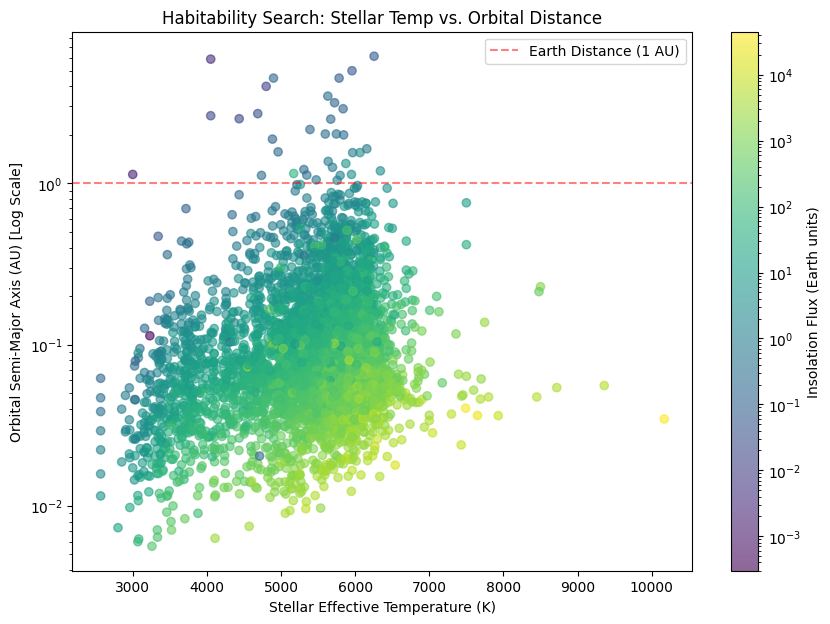

In [10]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(df_final['st_teff'], df_final['pl_orbsmax'], 
            c=df_final['pl_insol'], cmap='viridis', 
            alpha=0.6, norm=colors.LogNorm()) 

plt.colorbar(scatter, label='Insolation Flux (Earth units)')

# Use log to smooth out the wide range of orbital distances and make the plot more readable
plt.yscale('log') 

plt.title('Habitability Search: Stellar Temp vs. Orbital Distance')
plt.xlabel('Stellar Effective Temperature (K)')
plt.ylabel('Orbital Semi-Major Axis (AU) [Log Scale]')

# Add Earth's position for reference
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Earth Distance (1 AU)')
plt.legend()

plt.show()

**Key Insights from the Habitability Map**
- **The "1 AU Desert"**: Notice how the area directly on the red dashed line (1 AU) is surprisingly empty, especially for Sun-like stars (5000K-6000K). This is because detecting planets at 1 AU using the transit method is very difficult; they take a full year to orbit, and we need years of data to confirm them.

- **The Blue Chill (Left)**: To the left of the graph (cool stars), the dots below the line are blue. This means that even though they are closer than 1 AU, they receive very little energy ($10^{-1}$ or less) because their stars are weak. They are "Ice Worlds."

- **The Yellow Heat (Right)**: Around 5000K and above, the dots approaching the line from below are already yellow/light green. This means that at the same distance where Earth is safe, these planets are being "cooked" by their hotter stars ($10^{1}$ to $10^{2}$ insolation).

- **The Diagonal Gradient**: The "Habitable Zone" (the green/teal color, $10^{0}$) isn't a horizontal line; it's a diagonal that moves from the bottom-left to the top-right. This confirms that your GNN must learn a non-linear relationship: a planet at 0.1 AU can be "green" if the star is 3000K, but it will be "yellow" if the star is 6000K.

### Graph Topology: System Connectivity

Finally, we are going to analyze the **architecture of our dataset from a geometric perspective**. Since we are building a Graph Neural Network, it is essential to know how many "nodes" (planets) will be connected to each "hub" (star). This bar chart shows the distribution of planets per stellar system, which directly represents the connectivity of the graphs our model will learn from.

/tmp/ipykernel_35868/1810286112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=planets_per_system, palette='magma')


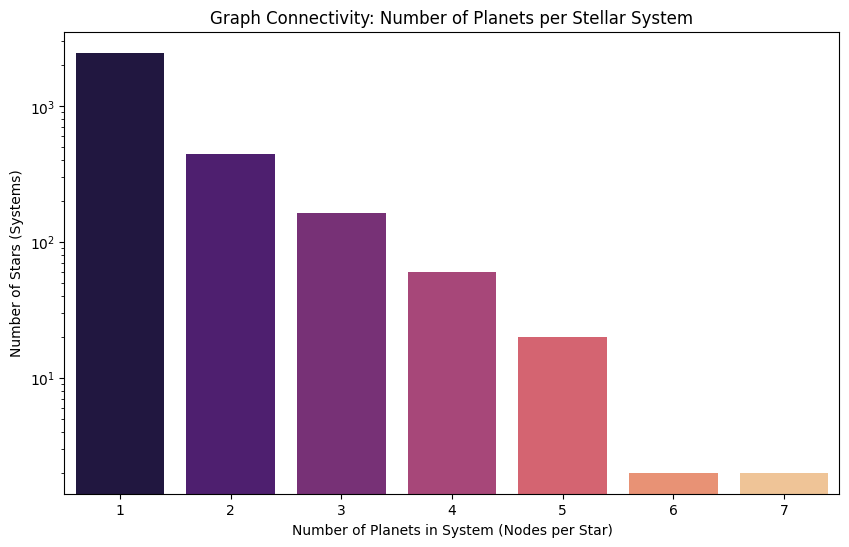

In [11]:
plt.figure(figsize=(10, 6))
# Contamos cuántos planetas hay por cada hostname
planets_per_system = df_final.groupby('hostname')['pl_name'].count()

sns.countplot(x=planets_per_system, palette='magma')
plt.title('Graph Connectivity: Number of Planets per Stellar System')
plt.xlabel('Number of Planets in System (Nodes per Star)')
plt.ylabel('Number of Stars (Systems)')
plt.yscale('log') # Escala logarítmica para ver mejor los sistemas raros de muchos planetas
plt.show()

**Key Insights from the System Connectivity**
- **The Power of Multi-Planetary Systems**: While many stars in the dataset have only one detected planet, there is a significant population of systems with 2, 3, or even 7 planets. These systems are key for a GNN because they provide rich relational data about orbital spacing and gravitational hierarchies.

- **Graph Density**: The systems with 4 to 7 planets will result in more complex graph structures. These allow the model to learn "neighborhood effects": how the presence of a large outer planet might correlate with the habitability of an inner rocky one.

- **Logarithmic Reality**: By using a log scale on the Y-axis, we can see that although systems with 6 or 7 planets are rare, they are still present in enough quantity to be representative. This variety ensures the GNN doesn't just learn simple star-planet pairs but also complex system dynamics.

- **Preparation for Message Passing**: This plot confirms that our "Message Passing" layers in the GNN will have diverse environments to work with. Some nodes will receive information from many neighbors, while others will be more isolated, providing a robust training set.

## Data Preprocessing

Now that our EDA is complete, we need to prepare the data for the Graph Neural Network (GNN). This involves two main steps: **Scaling** (making the numbers manageable) and **Topology** (defining the connections).

### Feature Scaling (Standardization)

In our EDA, we saw that `pl_insol` reaches $10,000$ while `pl_rade` is around $1$. To prevent large numbers from overwhelming the model, we use Standardization (Z-score normalization).

We use Standardization (Z-score) because it centers the data at a mean of $0$ and a standard deviation of $1$. Unlike Min-Max scaling, which would "crush" most of our data into a tiny range to fit extreme outliers, **Standardization preserves the relative distances between planets**. This allows the GNN to learn more efficiently through gradient descent, as it won't be distracted by the magnitude of the numbers.

In [12]:
# Select numeric columns for scaling
key_columns = [
    'sy_pnum',          # Number of planets in the system
    'pl_orbsmax',       # Distance from star
    'pl_rade',          # Planet radius
    'pl_bmasse',        # Planet mass
    'pl_insol',         # Energy received (Insolation)
    'pl_orbeccen',      # Orbit eccentricity
    'st_teff',          # Star temperature
    'st_mass',          # Star mass
    'st_met'            # Star metallicity
]

scaler = StandardScaler()
df_final[key_columns] = scaler.fit_transform(df_final[key_columns])

### Defining Graph Topology: Nodes and Edges

In a GNN, we need to represent our dataset as a set of Nodes connected by Edges:
- **Nodes ($X$)**: Each exoplanet is a node containing its physical features (mass, radius, temperature).
 
- **Edges (edge_index)**: Since planets are part of a system, we connect all planets that orbit the same star (hostname). We use a Fully Connected strategy for each system. This enables Message Passing, where a planet "shares" its information with its neighbors. This is physically relevant because the presence of a massive gas giant in a system can influence the orbital stability and habitability of a smaller rocky neighbor.

In [13]:
# Creamos una copia para no romper nada
df_final = df_final.copy()

# Definimos criterios de habitabilidad (basados en valores estandarizados)
# Un valor de 0 significa que es igual a la media (muy cercano a la Tierra)
is_earth_sized = (df_final['pl_rade'] > -0.5) & (df_final['pl_rade'] < 0.5)
is_in_hz = (df_final['pl_insol'] > -0.5) & (df_final['pl_insol'] < 0.5)

# Creamos la columna 'habitable_flag': 1 si cumple ambos, 0 si no
df_final['habitable_flag'] = (is_earth_sized & is_in_hz).astype(int)

# Verificamos cuántos "habitables" hemos encontrado
print(f"Planetas etiquetados como habitables: {df_final['habitable_flag'].sum()}")

Planetas etiquetados como habitables: 1718


In [14]:
from utils import build_graph_dataset   

# IMPORTANT: Make sure 'habitable_flag' exists in your df_final before this!
# If your column is named 'disposition' or something else, change it here:
target_column = 'habitable_flag' 

processed_graphs = build_graph_dataset(df_final, key_columns, target_column)

print(f"Dataset Construction Complete: {len(processed_graphs)} star systems generated.")
print(f"Example of first system: {processed_graphs[0]}")

Dataset Construction Complete: 3167 star systems generated.
Example of first system: Data(x=[1, 9], edge_index=[2, 1], y=[1], star_name='55 Cnc')


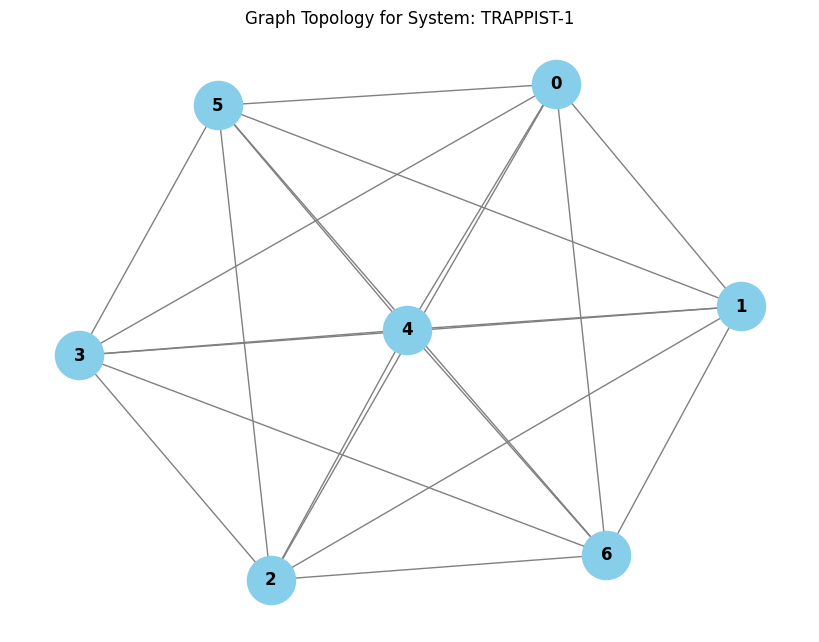

In [15]:
from utils import plot_stellar_graph   

# --- EJEMPLO DE USO ---
# Nota: En el dataset de la NASA, el Sol suele aparecer como "Sun" 
# o puedes probar con sistemas famosos como "TRAPPIST-1" o "HD 10180"
plot_stellar_graph(processed_graphs, "TRAPPIST-1")